# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

In [1]:
# Who: The audience would be Lending Club managers and loan analysts who are responsible for deciding which loans to approve and how to manage lending risk.

# What: I want them to understand which borrower characteristics are most closely linked to loan defaults. This information could help them make better lending decisions and reduce the number of loans that end up being charged off.

# How:I would use the Lending Club dataset to compare factors such as credit grade, debt-to-income ratio, annual income, and loan amount against loan outcomes. By creating clear visualizations that show default rates across different borrower groups, I could highlight patterns that help explain why some loans are more likely to fail than others.
# In short, the story I would tell is that certain borrower characteristics are strong indicators of loan risk, and understanding those patterns can help the company make smarter lending decisions.

# 3. Homework - work with your own data

In [6]:
!pip install pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 43.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 39.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [14]:
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [kagglehub]/4 [kagglesdk]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [15]:
import kagglehub

path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.26G/1.26G [00:12<00:00, 111MB/s] 

Extracting files...


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


In [19]:
import os

error_path = os.path.join(path, 'accepted_2007_to_2018q4.csv')

print("Contents of the folder:", os.listdir(error_path))

Contents of the folder: ['accepted_2007_to_2018Q4.csv']


In [21]:
import os
import pandas as pd

folder_path = os.path.join(path, 'accepted_2007_to_2018q4.csv')

files_inside = os.listdir(folder_path)
print("Files found inside the directory:", files_inside)

true_csv_path = os.path.join(folder_path, files_inside[0])
print("Dynamically loading from:", true_csv_path)

df_accepted = pd.read_csv(true_csv_path, nrows=5000)

print("\nSuccess! Accepted Loans Shape:", df_accepted.shape)
df_accepted.head()

Files found inside the directory: ['accepted_2007_to_2018Q4.csv']
Dynamically loading from: /home/codespace/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv


/tmp/ipykernel_17872/3887767169.py:12: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  df_accepted = pd.read_csv(true_csv_path, nrows=5000)



Success! Accepted Loans Shape: (5000, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
import pandas as pd
import os

folder_path = os.path.join(path, 'accepted_2007_to_2018q4.csv')
true_csv_path = os.path.join(folder_path, os.listdir(folder_path)[0])

df = pd.read_csv(true_csv_path, nrows=50000)

df.info()

df.describe()

/tmp/ipykernel_17872/3964213776.py:7: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(true_csv_path, nrows=50000)


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), str(36)
memory usage: 57.6 MB


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,5.000000e+04,0.0,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,49999.000000,50000.000000,...,406.0,406.000000,406.0,406.000000,325.000000,406.000000,406.000000,1537.000000,1537.000000,1537.000000
mean,6.670963e+07,NaN,15019.359500,15019.359500,15011.823500,12.234782,434.098806,7.919317e+04,19.338815,0.345500,...,3.0,129.777414,3.0,13.975369,385.143138,10431.307488,191.497044,5009.780507,47.000150,13.716331
std,1.942339e+06,NaN,8676.103295,8676.103295,8671.131769,4.191338,247.494017,1.013212e+05,9.810057,0.910201,...,0.0,106.781963,0.0,9.983413,320.478947,6537.325974,187.127673,3567.857376,5.367391,7.477062
min,6.702500e+04,NaN,1000.000000,1000.000000,950.000000,5.320000,14.770000,0.000000e+00,0.000000,0.000000,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.050000,186.000000,30.000000,0.000000
25%,6.594684e+07,NaN,8000.000000,8000.000000,8000.000000,9.170000,255.040000,4.800000e+04,12.680000,0.000000,...,3.0,47.817500,3.0,6.000000,142.440000,5190.170000,46.355000,2110.000000,45.000000,8.000000
50%,6.654286e+07,NaN,14000.000000,14000.000000,13900.000000,11.990000,378.150000,6.600000e+04,18.820000,0.000000,...,3.0,101.250000,3.0,14.500000,296.610000,9388.780000,130.515000,4292.650000,45.000000,14.000000
75%,6.744762e+07,NaN,20000.000000,20000.000000,20000.000000,14.480000,573.702500,9.500000e+04,25.615000,0.000000,...,3.0,180.137500,3.0,23.000000,527.370000,15055.480000,284.637500,7024.000000,50.000000,18.000000
max,6.861706e+07,NaN,35000.000000,35000.000000,35000.000000,28.990000,1354.660000,9.000000e+06,999.000000,15.000000,...,3.0,629.700000,3.0,30.000000,1889.100000,29401.040000,926.410000,22000.000000,75.000000,65.000000


In [24]:

print("Number of duplicate rows:", df.duplicated().sum())

print("Number of duplicate loan IDs:", df['id'].duplicated().sum())

Number of duplicate rows: 0
Number of duplicate loan IDs: 0


In [25]:
numeric_df = df.select_dtypes(include=['number'])

print("--- MEAN ---")
print(numeric_df.mean())

print("\n--- MEDIAN ---")
print(numeric_df.median())

print("\n--- MODE ---")

print(df.mode().iloc[0])

--- MEAN ---
id                                6.670963e+07
member_id                                  NaN
loan_amnt                         1.501936e+04
funded_amnt                       1.501936e+04
funded_amnt_inv                   1.501182e+04
                                      ...     
hardship_payoff_balance_amount    1.043131e+04
hardship_last_payment_amount      1.914970e+02
settlement_amount                 5.009781e+03
settlement_percentage             4.700015e+01
settlement_term                   1.371633e+01
Length: 115, dtype: float64

--- MEDIAN ---
id                                6.654286e+07
member_id                                  NaN
loan_amnt                         1.400000e+04
funded_amnt                       1.400000e+04
funded_amnt_inv                   1.390000e+04
                                      ...     
hardship_payoff_balance_amount    9.388780e+03
hardship_last_payment_amount      1.305150e+02
settlement_amount                 4.292650e+03
set

In [26]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

member_id                              50000
sec_app_chargeoff_within_12_mths       50000
sec_app_collections_12_mths_ex_med     50000
sec_app_mths_since_last_major_derog    50000
sec_app_mort_acc                       50000
                                       ...  
title                                    132
last_pymnt_d                              34
revol_util                                24
dti                                        1
last_credit_pull_d                         1
Length: 72, dtype: int64


In [27]:
df['dti'] = df['dti'].fillna(df['dti'].mean())

df['emp_title'] = df['emp_title'].fillna('Unknown')

df = df.dropna(subset=['loan_amnt'])

In [28]:
bad_logic = df[df['funded_amnt'] > df['loan_amnt']]
print(f"Rows with logical inconsistencies: {len(bad_logic)}")

Rows with logical inconsistencies: 0


In [29]:
columns_to_encode = ['application_type', 'verification_status']

df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)

df_encoded.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,application_type_Joint App,verification_status_Source Verified,verification_status_Verified
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,N,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,N,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,N,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,N,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,N,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False


In [30]:
print(df['loan_status'].value_counts())

print(df['loan_status'].value_counts(normalize=True) * 100)

loan_status
Fully Paid            34978
Charged Off            9027
Current                5610
Late (31-120 days)      246
In Grace Period         100
Late (16-30 days)        38
Default                   1
Name: count, dtype: int64
loan_status
Fully Paid            69.956
Charged Off           18.054
Current               11.220
Late (31-120 days)     0.492
In Grace Period        0.200
Late (16-30 days)      0.076
Default                0.002
Name: proportion, dtype: float64


# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough. If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 53.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 53.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 48.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


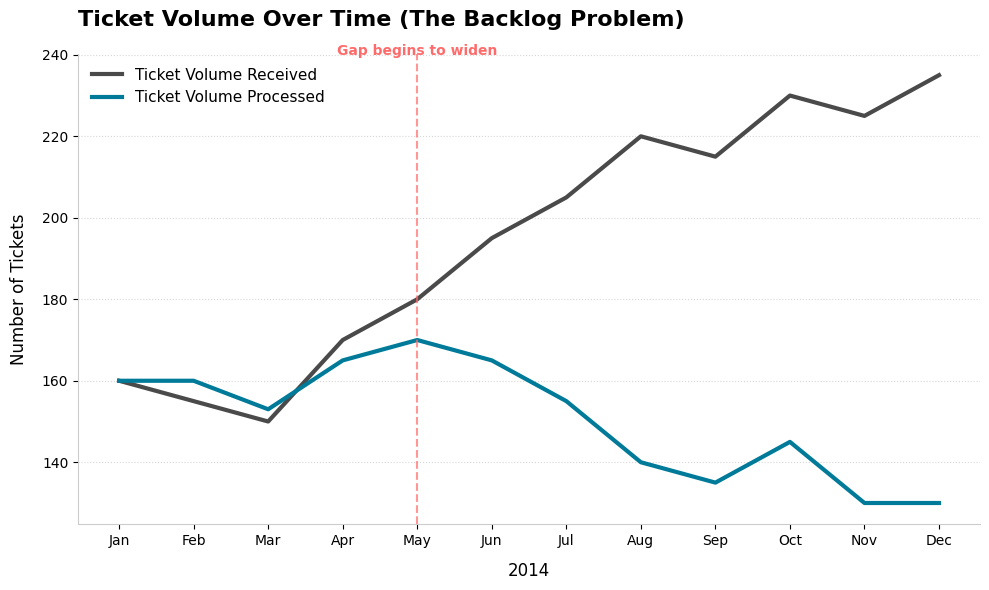

In [33]:
!pip install matplotlib
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
tickets_received = [160, 155, 150, 170, 180, 195, 205, 220, 215, 230, 225, 235]
tickets_processed = [160, 160, 153, 165, 170, 165, 155, 140, 135, 145, 130, 130]

plt.figure(figsize=(10, 6))

plt.plot(months, tickets_received, label='Ticket Volume Received', color='#4A4A4A', linewidth=3)
plt.plot(months, tickets_processed, label='Ticket Volume Processed', color='#007A99', linewidth=3)

plt.title('Ticket Volume Over Time (The Backlog Problem)', fontsize=16, fontweight='bold', pad=20, loc='left')
plt.xlabel('2014', fontsize=12, labelpad=10)
plt.ylabel('Number of Tickets', fontsize=12, labelpad=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.axvline(x='May', color='#FF6B6B', linestyle='--', alpha=0.7)
plt.text('May', 240, 'Gap begins to widen', color='#FF6B6B', fontweight='bold', ha='center')

plt.legend(frameon=False, fontsize=11, loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()